In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [3]:
# Load the iris dataset 
iris = load_iris()
df = pd.DataFrame(iris.data,columns=iris.feature_names)

In [4]:
# selectiong only two features for visualization
X = df[['sepal length (cm)','sepal width (cm)']].values

In [5]:
# standardizing the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
kmeans = KMeans(n_clusters=3, init = 'k-means++',random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

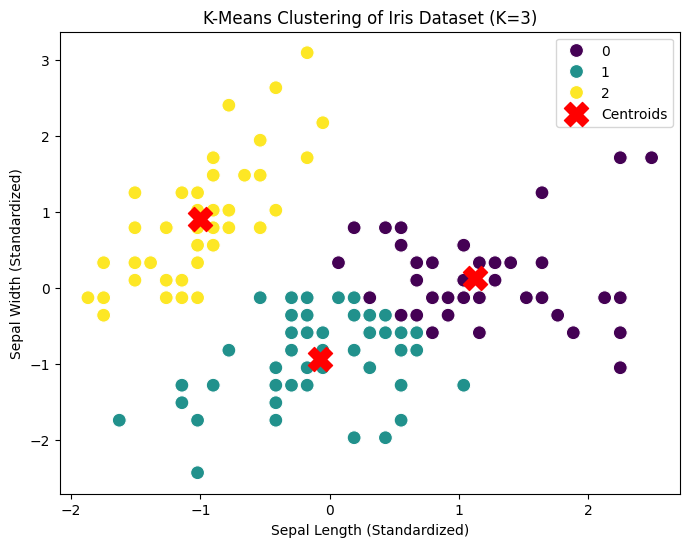

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y_kmeans, palette='viridis', s=100)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='red', marker='X', label='Centroids')
plt.xlabel('Sepal Length (Standardized)')
plt.ylabel('Sepal Width (Standardized)')
plt.title('K-Means Clustering of Iris Dataset (K=3)')
plt.legend()
plt.show()

In [ ]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
X

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6],
       [5.4, 3.9],
       [4.6, 3.4],
       [5. , 3.4],
       [4.4, 2.9],
       [4.9, 3.1],
       [5.4, 3.7],
       [4.8, 3.4],
       [4.8, 3. ],
       [4.3, 3. ],
       [5.8, 4. ],
       [5.7, 4.4],
       [5.4, 3.9],
       [5.1, 3.5],
       [5.7, 3.8],
       [5.1, 3.8],
       [5.4, 3.4],
       [5.1, 3.7],
       [4.6, 3.6],
       [5.1, 3.3],
       [4.8, 3.4],
       [5. , 3. ],
       [5. , 3.4],
       [5.2, 3.5],
       [5.2, 3.4],
       [4.7, 3.2],
       [4.8, 3.1],
       [5.4, 3.4],
       [5.2, 4.1],
       [5.5, 4.2],
       [4.9, 3.1],
       [5. , 3.2],
       [5.5, 3.5],
       [4.9, 3.6],
       [4.4, 3. ],
       [5.1, 3.4],
       [5. , 3.5],
       [4.5, 2.3],
       [4.4, 3.2],
       [5. , 3.5],
       [5.1, 3.8],
       [4.8, 3. ],
       [5.1, 3.8],
       [4.6, 3.2],
       [5.3, 3.7],
       [5. , 3.3],
       [7. , 3.2],
       [6.4, 3.2],
       [6.9,

EXERCISE: 3

In [16]:
X = np.array([
    [2,3,4],
    [3,5,6],
    [5,8,9],
    [6,9,11],
    [7,10,13]])

In [17]:
X

array([[ 2,  3,  4],
       [ 3,  5,  6],
       [ 5,  8,  9],
       [ 6,  9, 11],
       [ 7, 10, 13]])

In [18]:
# compute mean value for each column
mean_x = np.mean(X,axis= 0)
print(mean_x)

[4.6 7.  8.6]


In [ ]:
# center the data
x_centered = X-mean_x

print(x_centered)

[[-2.6 -4.  -4.6]
 [-1.6 -2.  -2.6]
 [ 0.4  1.   0.4]
 [ 1.4  2.   2.4]
 [ 2.4  3.   4.4]]


In [23]:
# computer the covariance of the matrix
cov_matrix = np.cov(x_centered,rowvar=False)
print(cov_matrix)

[[ 4.3   6.    7.55]
 [ 6.    8.5  10.5 ]
 [ 7.55 10.5  13.3 ]]


In [25]:
# computer eignenvalues and eigenvectore
eigenvalues,eigenvecotes = np.linalg.eig(cov_matrix)
print(eigenvalues)
print(eigenvecotes)

[2.59637803e+01 5.52557327e-03 1.30694106e-01]
[[ 0.4066816   0.90812885  0.09955937]
 [ 0.56930735 -0.16669075 -0.80504865]
 [ 0.71449228 -0.38407836  0.58479449]]


In [26]:
# select the principle component(soriting by largest eigenvalues)
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvecotes = eigenvecotes[:,sorted_indices]

In [28]:
# Transform the dataset 
# 3 to 1 (project onto first principle component)
X_transformerd_1 = x_centered @ eigenvecotes[:,0]


In [29]:
# 3 to 2 (project onto first two princple components0)
X_transformerd_2 = x_centered @ eigenvecotes[:,:2]

In [32]:
# output result
print('Transformed Data (3 to 1):',X_transformerd_1)
print('Transformed Data (3 to 2):\n',X_transformerd_2)


Transformed Data (3 to 1): [-6.62126605 -3.64698519  1.0177769   3.42275041  5.82772392]
Transformed Data (3 to 2):
 [[-6.62126605  0.27128556]
 [-3.64698519 -0.06966338]
 [ 1.0177769  -0.5313071 ]
 [ 3.42275041 -0.0672074 ]
 [ 5.82772392  0.39689231]]
